# MovieLens Analysis with Spark

Using the MovieLens dataset (available at: https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset; use the files `movie.csv` and `rating.csv`), answer the following questions:

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.sql.window import Window
import time
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession \
    .builder \
    .appName("MovieLens Analysis") \
    .getOrCreate()

In [3]:
movies = spark.read.csv("movie.csv", header=True, inferSchema=True)
ratings = spark.read.csv("rating.csv", header=True, inferSchema=True)

In [4]:
movies.count()

27278

In [5]:
ratings.count()

6981891

In [6]:
movies.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


In [7]:
ratings.show(5)

+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows


1. Find the top 5 most active users.

In [8]:
top_5_users = ratings. \
              groupBy("userId"). \
              count(). \
              orderBy(F.desc("count")). \
              limit(5)

top_5_users.show()

+------+-----+
|userId|count|
+------+-----+
|  8405| 7515|
| 34576| 5356|
|  8963| 4524|
| 15617| 4354|
| 20132| 4101|
+------+-----+



2. Find the top 5 highest-rated movies.

In [9]:
top_5_rated = ratings. \
              groupBy("movieId"). \
              agg(F.avg("rating").alias("avg_rating"),
                  F.count("rating").alias("num_ratings")). \
              filter(F.col("num_ratings") >= 100). \
              orderBy(F.desc("avg_rating")). \
              limit(5)

top_5_rated = top_5_rated.join(movies, "movieId")
top_5_rated.select("movieId", "title", "avg_rating", "num_ratings").show(truncate=False)

+-------+-------------------------------------------+-----------------+-----------+
|movieId|title                                      |avg_rating       |num_ratings|
+-------+-------------------------------------------+-----------------+-----------+
|50     |Usual Suspects, The (1995)                 |4.343740499787195|16447      |
|318    |Shawshank Redemption, The (1994)           |4.452902816773843|22082      |
|527    |Schindler's List (1993)                    |4.311197546987678|17611      |
|858    |Godfather, The (1972)                      |4.343646294247788|14464      |
|2019   |Seven Samurai (Shichinin no samurai) (1954)|4.278189910979228|4044       |
+-------+-------------------------------------------+-----------------+-----------+



3. Define what a “popular” movie is and find all movies that satisfy your definition.

In [10]:
# movie is popular when it has more than 10.000 ratings
popular_movies = ratings. \
                 groupBy("movieId"). \
                 count(). \
                 filter(F.col("count") > 10000). \
                 orderBy(F.desc("count")). \
                 limit(10)

popular_movies = popular_movies.join(movies, "movieId")

popular_movies.select("movieId", "title", "count").show()

+-------+--------------------+-----+
|movieId|               title|count|
+-------+--------------------+-----+
|    110|   Braveheart (1995)|18720|
|    260|Star Wars: Episod...|19058|
|    296| Pulp Fiction (1994)|23326|
|    318|Shawshank Redempt...|22082|
|    356| Forrest Gump (1994)|23055|
|    480|Jurassic Park (1993)|20933|
|    527|Schindler's List ...|17611|
|    589|Terminator 2: Jud...|18254|
|    593|Silence of the La...|21897|
|   2571|  Matrix, The (1999)|17994|
+-------+--------------------+-----+



4. For each day of the week, find the most popular genre.

In [11]:
ratings = ratings. \
          withColumn("day_of_week", F.date_format("timestamp", "EEEE"))

movies_genres = movies. \
                withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))

joined = ratings.join(movies_genres, "movieId")

popular_genre = joined. \
                groupBy("day_of_week", "genre"). \
                count(). \
                orderBy("day_of_week", F.desc("count"))

window = Window.partitionBy("day_of_week"). \
         orderBy(F.desc("count"))

most_popular_genre = popular_genre. \
                     withColumn("rank", F.row_number().over(window)). \
                     filter(F.col("rank") == 1).\
                     orderBy(F.col("count")). \
                     select("day_of_week", "genre", "count")

most_popular_genre.show()

+-----------+-----+------+
|day_of_week|genre| count|
+-----------+-----+------+
|   Saturday|Drama|415178|
|     Friday|Drama|418752|
|   Thursday|Drama|420736|
|  Wednesday|Drama|442621|
|     Sunday|Drama|445081|
|    Tuesday|Drama|466536|
|     Monday|Drama|476983|
+-----------+-----+------+



5. Define one additional analytical question of your own and solve it using the skills gained during the practical sessions. Try to experiment with functions that were not used in class.

In [13]:
# Which genres have the highest average rating among popular movies (≥ 1000)
# Explode genres for every rating row, then aggregate
rated_genres = ratings.join(movies_genres, "movieId")

genre_stats = rated_genres. \
              groupBy("genre"). \
              agg(
                  F.count("rating").alias("total_ratings"),
                  F.avg("rating").alias("avg_rating"),
                  F.percentile_approx("rating", 0.5).alias("median_rating")
              ). \
              filter(F.col("total_ratings") >= 1000). \
              orderBy(F.desc("avg_rating"))

genre_stats.show(20, truncate=False)

+-----------+-------------+------------------+-------------+
|genre      |total_ratings|avg_rating        |median_rating|
+-----------+-------------+------------------+-------------+
|Film-Noir  |75339        |3.9625227305910617|4.0          |
|War        |365790       |3.8111238688865194|4.0          |
|Documentary|86232        |3.741557658409871 |4.0          |
|Crime      |1150900      |3.6752571900251976|4.0          |
|Drama      |3085887      |3.67497870142361  |4.0          |
|Mystery    |545322       |3.6622188358437766|4.0          |
|IMAX       |172203       |3.650281934693356 |4.0          |
|Animation  |398632       |3.6191926388247806|4.0          |
|Western    |147235       |3.568519713383367 |4.0          |
|Musical    |302365       |3.5571015163792103|4.0          |
|Romance    |1324772      |3.539618138064512 |4.0          |
|Thriller   |1857842      |3.505942109178283 |3.5          |
|Fantasy    |738880       |3.5035242529233432|3.5          |
|Adventure  |1531968    

6. Take one join operation from your analysis:

    6.1. Run .explain() and identify the join type (e.g., SortMergeJoin, BroadcastHashJoin).

    6.2. Modify the join strategy:
    
        * If Spark uses a SortMergeJoin, then apply a broadcast join using broadcast()  .
    
        * If Spark already uses a BroadcastHashJoin, then disable broadcasting to force a SortMergeJoin .
    
    6.3. Compare execution plans before and after.
    
    6.4. Explain:
    
        * What changed in the physical plan.
    
        * Why the performance might differ between the two approaches.

In [14]:
joined.explain() # BroadcastHashJoin

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, day_of_week#168, title#18, genres#19, genre#170]
   +- BroadcastHashJoin [movieId#38], [movieId#17], Inner, BuildRight, false
      :- Project [userId#37, movieId#38, rating#39, timestamp#40, date_format(timestamp#40, EEEE, Some(Etc/UTC)) AS day_of_week#168]
      :  +- Filter isnotnull(movieId#38)
      :     +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [isnotnull(movieId#38)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/rating.csv], PartitionFilters: [], PushedFilters: [IsNotNull(movieId)], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- BroadcastExchange HashedRelationBroadcastMode(List(cast(input[0, int, true] as bigint)),false), [plan_id=1319]
         +- Generate explode(split(genres#19, \|, -1)), [movieId#17, title#18, genres#19], false, [genre#170]
            +

In [15]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1) # disable broadcasting

In [16]:
sort_merge_join = ratings.join(movies_genres, "movieId")
sort_merge_join.explain() # SortMergeJoin

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, day_of_week#168, title#18, genres#19, genre#170]
   +- SortMergeJoin [movieId#38], [movieId#17], Inner
      :- Sort [movieId#38 ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(movieId#38, 200), ENSURE_REQUIREMENTS, [plan_id=1354]
      :     +- Project [userId#37, movieId#38, rating#39, timestamp#40, date_format(timestamp#40, EEEE, Some(Etc/UTC)) AS day_of_week#168]
      :        +- Filter isnotnull(movieId#38)
      :           +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [isnotnull(movieId#38)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/rating.csv], PartitionFilters: [], PushedFilters: [IsNotNull(movieId)], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- Sort [movieId#17 ASC NULLS FIRST], false, 0
         +- Exchange hashpartitioning(movieId#17, 

### **Before optimization: BroadcastHashJoin**

BroadcastHashJoin [movieId#38], [movieId#17], Inner, BuildRight, false

Spark broadcasts the movies table to all worker nodes:
The join is performed locally on each node, without shuffling the large dataset (ratings).


### **After Optimization: SortMergeJoin**

SortMergeJoin [movieId#38], [movieId#17], Inner

Both datasets are:

* Repartitioned:

    * Exchange hashpartitioning(movieId, 200)

* Sorted:

    * Sort [movieId ASC]

Then Spark performs a merge join on sorted data

**Conclusion:**
Initially, Spark used a BroadcastHashJoin because the movies dataset is small enough to be broadcast. This avoids expensive shuffle operations and results in faster execution.

After disabling broadcasting, Spark switched to SortMergeJoin. Since during SortMergeJoin Repartitioned and Sorting were done and it requires more disk and network I/O, more CPU work. This makes less efficient compared to BroadcastHashJoin.


7. Implement a custom transformation using:
   
    7.1. A PySpark UDF
   
    7.2. A Pandas UDF
   
    7.3. A Spark built-in function
   
    7.4. Measure execution time using actions and compare performance (also visualize).
   
    7.6. Explain:
   
        * Why one approach is faster.
   
        * What role Spark optimization plays.

In [17]:
def rating_category(r):
    if r >= 4:
        return "Good"
    elif r >= 2:
        return "Average"
    return "Bad"

udf_func = F.udf(rating_category, StringType())

start = time.time()
df_udf = ratings.withColumn("pyspark_category", udf_func("rating")).count()
udf_time = time.time() - start

print(f"UDF Time: {udf_time:.2f}")

UDF Time: 3.78


In [18]:
@F.pandas_udf(StringType())
def pandas_rating_category(ratings: pd.Series) -> pd.Series:
    return pd.cut(
        ratings,
        bins=[-float("inf"), 2, 4, float("inf")],
        labels=["Bad", "Average", "Good"],
        right=False          # [2,4) → Average, [4,Inf) → Good
    ).astype(str)

start = time.time()

df_pandas = ratings.withColumn("pandas_category", pandas_rating_category(F.col("rating"))).count()

pandas_time = time.time() - start

print(f"Pandas UDF Time: {pandas_time:.2f}")

Pandas UDF Time: 2.73


In [19]:
builtin_expr = (
    F.when(F.col("rating") >= 4, "Good")
     .when(F.col("rating") >= 2, "Average")
     .otherwise("Bad")
)
start = time.time()
df_builtin = ratings.withColumn("builtin_category", builtin_expr)
count_builtin = df_builtin.count()
builtin_time = time.time() - start

print(f"Built-in Time: {builtin_time:.2f}")

Built-in Time: 2.44


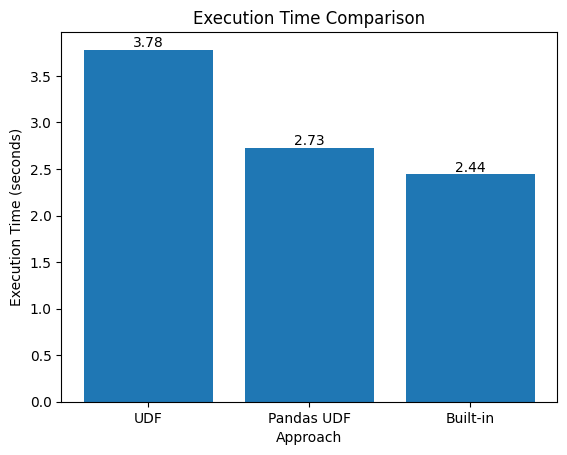

In [20]:
times = ["UDF", "Pandas UDF", "Built-in"]
values = [udf_time, pandas_time, builtin_time]

bars = plt.bar(times, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.ylabel("Execution Time (seconds)")
plt.xlabel("Approach")
plt.title("Execution Time Comparison")
plt.show()

### Explanation of Measured Execution Times

**Observed Results (from execution above):**
- **PySpark UDF:** ~3.78 seconds
- **Pandas UDF:** ~2.73 seconds
- **Built-in:** ~2.44 seconds

#### **Built-in Approach**

F.when(...).otherwise(...) is a Catalyst expression — pure JVM. And there are 3 optimisation layers:
1. Catalyst optimiser — before execution even starts, Spark's query planner analyses the when tree, folds constants, reorders branches by selectivity, and combines this expression with adjacent operations (like the .count() action) into a single stage.
2. Tungsten whole-stage code generation — Catalyst generates a single specialised JVM bytecode method for the entire pipeline stage. Instead of a loop that calls a virtual method per row, it emits a tight bytecode loop with zero heap allocation per row — data stays in CPU registers and L1 cache.
3. No JVM↔Python boundary — the computation never leaves the JVM. No serialisation, no socket, no inter-process overhead at all.

#### **Pandas UDF**

Apache Arrow serialises an entire partition (~30,000 rows) into a single contiguous columnar buffer and sends it across in one shot. On the Python side, pd.cut() operates on the whole pd.Series using NumPy's compiled C code — no Python interpreter loop.

#### **PySpark UDF**

Every single row takes a round-trip: JVM pickles the value -> sends it over an internal socket -> Python worker unpickles it -> runs rating_category(r) through the Python interpreter -> pickles the result -> sends it back -> JVM unpickles.